In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches

# Import 1135 leaf ionome dataset

In [2]:
df_1001=pd.read_table('1135_leaf_ionome.txt')
df_1001.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Li7,Na23,...,Fe57,Co59,Cu65,Zn66,As75,Se82,Rb85,Sr88,Mo98,Cd114
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,13.533427,1989.385107,...,138.401580,1.827647,7.052531,98.274997,1.151200,71.442057,391.846982,62.937324,5.052709,2.448871
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,15.194267,2189.845711,...,139.236192,2.404636,8.692987,101.369937,0.961746,80.210170,352.172133,67.492959,5.875919,2.932134
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,14.933369,1898.967428,...,138.563407,2.078383,9.324010,90.119590,1.000845,80.952731,366.533365,66.630082,4.893860,2.737883
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,13.951764,728.667266,...,137.832993,1.843778,7.985748,89.160879,0.979777,83.333572,483.749994,62.559302,5.164345,2.349769
4,265,PYL-6,France,44.6500,-1.166670,CS77198,leaf,France_leaf,13.954460,944.421617,...,142.203851,2.545781,9.120528,91.621874,1.279418,65.267342,386.146591,65.702393,22.864612,2.725846


In [3]:
df_1001.shape

(1161, 26)

# Comnbine it with 1135 leaf ionome dataset

In [4]:
list_accessions=pd.read_table('list_accessions_1135ionome-1135gwas.txt',header=None)
list_accessions.head()

,0
0,88
1,108
2,139
3,159
4,265


In [5]:
list_accessions=list_accessions.rename(columns={0:'Accession_ID'})
list_accessions.head()

,Accession_ID
0,88
1,108
2,139
3,159
4,265


In [6]:
list_accessions.shape[0]

1003

In [7]:
df_1001_merged=pd.merge(df_1001,list_accessions)
df_1001_merged.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Li7,Na23,...,Fe57,Co59,Cu65,Zn66,As75,Se82,Rb85,Sr88,Mo98,Cd114
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,13.533427,1989.385107,...,138.401580,1.827647,7.052531,98.274997,1.151200,71.442057,391.846982,62.937324,5.052709,2.448871
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,15.194267,2189.845711,...,139.236192,2.404636,8.692987,101.369937,0.961746,80.210170,352.172133,67.492959,5.875919,2.932134
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,14.933369,1898.967428,...,138.563407,2.078383,9.324010,90.119590,1.000845,80.952731,366.533365,66.630082,4.893860,2.737883
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,13.951764,728.667266,...,137.832993,1.843778,7.985748,89.160879,0.979777,83.333572,483.749994,62.559302,5.164345,2.349769
4,265,PYL-6,France,44.6500,-1.166670,CS77198,leaf,France_leaf,13.954460,944.421617,...,142.203851,2.545781,9.120528,91.621874,1.279418,65.267342,386.146591,65.702393,22.864612,2.725846


In [8]:
df_1001_merged['Mg/Col-0']=df_1001_merged['Mg25']/df_1001_merged.loc[df_1001_merged['Name'] == 'Col-0','Mg25'].item()
df_1001_merged.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Li7,Na23,...,Co59,Cu65,Zn66,As75,Se82,Rb85,Sr88,Mo98,Cd114,Mg/Col-0
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,13.533427,1989.385107,...,1.827647,7.052531,98.274997,1.151200,71.442057,391.846982,62.937324,5.052709,2.448871,0.789994
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,15.194267,2189.845711,...,2.404636,8.692987,101.369937,0.961746,80.210170,352.172133,67.492959,5.875919,2.932134,0.777822
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,14.933369,1898.967428,...,2.078383,9.324010,90.119590,1.000845,80.952731,366.533365,66.630082,4.893860,2.737883,0.796113
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,13.951764,728.667266,...,1.843778,7.985748,89.160879,0.979777,83.333572,483.749994,62.559302,5.164345,2.349769,0.841582
4,265,PYL-6,France,44.6500,-1.166670,CS77198,leaf,France_leaf,13.954460,944.421617,...,2.545781,9.120528,91.621874,1.279418,65.267342,386.146591,65.702393,22.864612,2.725846,0.718132


# Filter for European accessions

In [9]:
Europe=df_1001_merged.loc[(df_1001_merged['Latitude']>36.52) & (df_1001_merged['Latitude']<68.80) & (df_1001_merged['Longitude']>-8.54) & (df_1001_merged['Longitude']<38.28)]
Europe.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Li7,Na23,...,Co59,Cu65,Zn66,As75,Se82,Rb85,Sr88,Mo98,Cd114,Mg/Col-0
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,13.533427,1989.385107,...,1.827647,7.052531,98.274997,1.151200,71.442057,391.846982,62.937324,5.052709,2.448871,0.789994
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,15.194267,2189.845711,...,2.404636,8.692987,101.369937,0.961746,80.210170,352.172133,67.492959,5.875919,2.932134,0.777822
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,14.933369,1898.967428,...,2.078383,9.324010,90.119590,1.000845,80.952731,366.533365,66.630082,4.893860,2.737883,0.796113
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,13.951764,728.667266,...,1.843778,7.985748,89.160879,0.979777,83.333572,483.749994,62.559302,5.164345,2.349769,0.841582
4,265,PYL-6,France,44.6500,-1.166670,CS77198,leaf,France_leaf,13.954460,944.421617,...,2.545781,9.120528,91.621874,1.279418,65.267342,386.146591,65.702393,22.864612,2.725846,0.718132


In [10]:
Europe.shape

(843, 27)

In [11]:
Europe_Mg=Europe[['Accession_ID','Name','Mg25','Mg/Col-0']]
Europe_Mg.head()

,Accession_ID,Name,Mg25,Mg/Col-0
0,88,CYR,4513.790113,0.789994
1,108,LDV-18,4444.244161,0.777822
2,139,LDV-46,4548.751871,0.796113
3,159,MAR2-3,4808.545837,0.841582
4,265,PYL-6,4103.189376,0.718132


In [12]:
Europe_Mg=Europe_Mg.rename(columns={'Accession_ID':'Seq_ID',
                   'Name':'Sample_ID',
                   'Mg25':'Mg'})
Europe_Mg.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0
0,88,CYR,4513.790113,0.789994
1,108,LDV-18,4444.244161,0.777822
2,139,LDV-46,4548.751871,0.796113
3,159,MAR2-3,4808.545837,0.841582
4,265,PYL-6,4103.189376,0.718132


In [13]:
Europe_Mg['Population']='Europe'
Europe_Mg.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0,Population
0,88,CYR,4513.790113,0.789994,Europe
1,108,LDV-18,4444.244161,0.777822,Europe
2,139,LDV-46,4548.751871,0.796113,Europe
3,159,MAR2-3,4808.545837,0.841582,Europe
4,265,PYL-6,4103.189376,0.718132,Europe


# Import Santo Antao leaf ionome dataset

In [14]:
SA=pd.read_table('SantoAntao_jiffy_20240307.txt')
SA.head()

,Seq_ID,Sample_ID,Mg24
0,22615,S1-100,2624.01
1,22628,S10-100,3146.22
2,2876_AM,S10-101,3038.21
3,22637,S10-102,3065.45
4,27158,S10-12,2601.31


In [15]:
SA.shape

(109, 3)

In [16]:
SA['Mg/Col-0']=SA['Mg24']/SA.loc[SA['Sample_ID'] == 'Col-0','Mg24'].item()
SA.head()

,Seq_ID,Sample_ID,Mg24,Mg/Col-0
0,22615,S1-100,2624.01,0.676946
1,22628,S10-100,3146.22,0.811666
2,2876_AM,S10-101,3038.21,0.783801
3,22637,S10-102,3065.45,0.790829
4,27158,S10-12,2601.31,0.671089


In [17]:
SA=SA.rename(columns={'Mg24':'Mg'})
SA.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0
0,22615,S1-100,2624.01,0.676946
1,22628,S10-100,3146.22,0.811666
2,2876_AM,S10-101,3038.21,0.783801
3,22637,S10-102,3065.45,0.790829
4,27158,S10-12,2601.31,0.671089


In [18]:
SA['Population']='SA'
SA.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0,Population
0,22615,S1-100,2624.01,0.676946,SA
1,22628,S10-100,3146.22,0.811666,SA
2,2876_AM,S10-101,3038.21,0.783801,SA
3,22637,S10-102,3065.45,0.790829,SA
4,27158,S10-12,2601.31,0.671089,SA


# Combine datasets

In [19]:
combined=pd.concat([Europe_Mg,SA])
combined.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0,Population
0,88,CYR,4513.790113,0.789994,Europe
1,108,LDV-18,4444.244161,0.777822,Europe
2,139,LDV-46,4548.751871,0.796113,Europe
3,159,MAR2-3,4808.545837,0.841582,Europe
4,265,PYL-6,4103.189376,0.718132,Europe


### Remove Col-0 and Cvi-0

In [20]:
combined_noColO_Cvi=combined.loc[(combined['Sample_ID'] != 'Col-0') | (combined['Sample_ID'] != 'Cvi-0')]
combined_noColO_Cvi.head()

,Seq_ID,Sample_ID,Mg,Mg/Col-0,Population
0,88,CYR,4513.790113,0.789994,Europe
1,108,LDV-18,4444.244161,0.777822,Europe
2,139,LDV-46,4548.751871,0.796113,Europe
3,159,MAR2-3,4808.545837,0.841582,Europe
4,265,PYL-6,4103.189376,0.718132,Europe


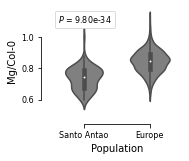

In [21]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

europe=combined[combined_noColO_Cvi['Population'] == 'Europe']
santoantao=combined[combined_noColO_Cvi['Population'] == 'SA']

Order=['SA','Europe']

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(6*cm,5*cm))
ax=sns.violinplot(x='Population', 
            y='Mg/Col-0',
            color='grey',
            data=combined,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
# r,p = mannwhitneyu(leaf[leaf['top_peak'] == 'alt'],leaf[leaf['top_peak'] == 'ref'])
r,p = mannwhitneyu(europe['Mg/Col-0'],santoantao['Mg/Col-0'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='upper left', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xticklabels(['Santo Antao', 'Europe'])

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
# plt.xlabel('$\itCNNM1$ L77fs',fontsize=10)
# plt.xlabel('$\itBOR2$ S313G',fontsize=10)
# plt.ylabel('Leaf [B] \n(µg/g DW)',fontsize=10)
# plt.savefig("FigS8.pdf", format="pdf",bbox_inches="tight",facecolor="w")